# Examples for the Principles introduced

This notebook contains examples for the principlies discussed in 'Dimensions of Power: A Systematic Guide to Power Indices for
Explainable AI' paper.
As a running example we consider the follwoing binary classifier $\kappa$ over the binary feature-set $\{\mathbf{x_1,x_2,x_3}\}$.
The output of $\kappa$ is dictated by the table below.

 | $x_1$ | $x_2$ | $x_3$ | $\kappa$ (classifier) |
 | :-: | :-: | :-: | :-: |
 | 0 | 0 | 0 | 0 |
 | 0 | 0 | 1 | 0 |
 | 0 | 1 | 0 | 1 |
 | 0 | 1 | 1 | 1 |
 | 1 | 0 | 0 | 0 |
 | 1 | 0 | 1 | 0 |
 | 1 | 1 | 0 | 0 |
 | 1 | 1 | 1 | 0 |

Run the cell below to instantiate $\kappa$.

In [7]:
def classifier( data_pt: list[int] )-> int:
  """ Returns the value of classifier corresponding to the example
      in explanantion is not a game

      Args:
      data_pt (list[int]): A binary list of length 3.

      Returns:
      int: The value of classifier.
  """

  if( data_pt == [0, 1, 0] or
       data_pt == [0, 1, 1]
       ):       return 1

  else :    return 0

In this notebook, we primarily provide negative examples corresponding to the principles introduced. For the power indices we mainly work with Shapley values, Banzhaf values, Owne values, Upsilon values and the counterfactual index.

The `binary_value_function` given below provides the template of $\textit{all}$ the value functions $f:\{{\bf x_1, x_2, x_3}\}\rightarrow \{0,1\}$; `binary_value_function_over_set` generates all the value functions w.r.t. $\{{\bf x_1, x_2, x_3}\}$. Run the cell below to instantiate them.


In [6]:
from itertools import combinations
from typing import Any

def powerset(s: list[int])-> list[list]:
    """Returns the powerset of a set.

       Args:
       s (list[int]): a set of integers.

       Returns:
       list([list]): all the possible subset fo s.
    """
    subset = []
    for i in range(0, len(s) + 1):
      for j in combinations(s, i): subset.append(list(j))

    return subset

def binary_value_function(players: list[int],
                          designated_set: list[list])-> dict:
    """
       Returns a binary value based on the input of the form (x,y,z), w.r.t. the designated set.

       Args:
       inp (list[int]): Input for the player.
       designated_set (list[list]): The set of players against which the function evaluates.

       Returns:
       dict: The corresponding value of each coalition.
    """
    function = {}
    power = powerset(players)
    for i in power:
      s = ''
      s = s.join([str(pl) for pl in i])
      if (i in designated_set): function.update({s: 1})
      else:                     function.update({s: 0})

    return function

def binary_value_functions_over_set(players: list[int],
                                    )-> list[dict]:

    """
       Returns a list of all possible binary value function over players.

       Args:
       players (list[int]): List of players to be passed on.

       Returns:
       list[dict]: The list of all possible binary value functions over players.
    """
    functions = []
    power = powerset(players)

    for i in range(0, (len(power) + 1)):
        for comb in combinations(power, i):
            f = binary_value_function(players, list(comb))
            functions.append(f)

    return functions

def function_dict_to_callable(players: list[Any],
                              coalition: set[Any],
                              set_func: dict,)-> int:
    """
       Returns the value of the of player_index from set_func.

       Args:
       set_func (dict): The binary value function.
       player_index (int): The index of the player.
       coalition (set[Any]): The coalition of players in form of a set.

       Returns:
       int: The value of the player.
    """
    coalition = list(coalition)
    coalition_string = ''.join([str(x) for x in coalition])
    return set_func[coalition_string]

def function_dict_to_callable_string(players: list[Any],
                                     coalition: str,
                                     set_func: dict,)-> int:
    """
       Returns the value of the of player_index from set_func.

       Args:
       set_func (dict): The binary value function.
       player_index (int): The index of the polayer.
       coalition (str): The coalition of players.

       Returns:
       int: The value of the player.
    """

    return set_func[coalition]


The cardinality index is implemented in the cell below.

In [1]:
from typing import Callable

def cardinality_index(players: list[int],
                      value_function: dict,
                      )-> list[float]:
    """
       The cardinality based power index.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       list[float]: The list of values corresponding to the players in players.
    """
    values = {}
    players_whole = ''.join([str(x) for x in players])

    for i in range(1, len(players) + 1):
      players_without_i = ''.join([str(x) for x in players if x != i])
      value = value_function[players_whole] - value_function[players_without_i]
      values.update({i: value})

    return values

## The principle of Success

First, we consider the principle of success. The idea is to plot the positive and negative instances of success principles w.r.t. all the binary value functions against the power index at hand. Towards that, we implement the success checks.

In [4]:
from functools import partial
from powerxai.banzhaf_value import banzhaf_value as bv
from powerxai.shapley_value import shapley_value as sv
from powerxai.owen_value import owen_value as ov
from powerxai.upsilon_value import upsilon_value as uv
from powerxai.coalitions import maximal_chains


def success_for_cardinality_index(players: list[int],
                                  value_function: dict)-> bool:
    """
       Checks whether the cardinality index satisfies the success principle.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       bool: The truth value of the success principle.
    """

    cardinality = cardinality_index(players, value_function)
    for player in cardinality:
       if(cardinality[player] != 0): return True

    return False


def success_for_banzhaf_index(players: list[int],
                                  value_function: dict)-> bool:
    """
       Checks whether the banzhaf index satisfies the success principle.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       bool: The truth value of the success principle.
    """
    values = []
    func = partial(function_dict_to_callable, set_func=value_function)

    for i in players:
      values.append(bv(i, players, func, probabilistic= True))

    for v in values:
       if(v != 0.0): return True


    return False


def success_for_shapley_index(players: list[int],
                                  value_function: dict)-> bool:
    """
       Checks whether the banzhaf index satisfies the success principle.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       bool: The truth value of the success principle.
    """
    values = []
    func = partial(function_dict_to_callable, set_func=value_function)

    for i in players:
      values.append(sv(i, players, func))

    for v in values:
       if(v != 0.0): return True


    return False


def success_for_owen_index(players: list[list[int]],
                           value_function: dict,
                           )-> bool:
    """
       Checks whether the banzhaf index satisfies the success principle.

       Args:
       players (list[list[int]]): List of partitioned players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       bool: The truth value of the success principle.
    """
    values = []
    func = partial(function_dict_to_callable, set_func=value_function)

    for i in range(0, len(players)+1):
      values.append(ov(i, players, func))

    for v in values:
       if(v != 0.0): return True


    return False


def success_for_upsi_index(players: list[int],
                           value_function: dict,
                           )-> bool:
    """
       Checks whether the banzhaf index satisfies the success principle.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function to be used.

       Returns:
       bool: The truth value of the success principle.
    """
    values = []
    func = partial(function_dict_to_callable, set_func=value_function)

    for i in players:
      values.append(uv(i+1, players, func))

    for v in values:
       if(v != 0.0): return True


    return False

Now, we plot the bar graphs highlighting the positive and negative instances of the principle of success w.r.t. all the binary value functions over the feature set $\{{\bf x_1, x_2, x_3}\}$.  

### Upsilon Index

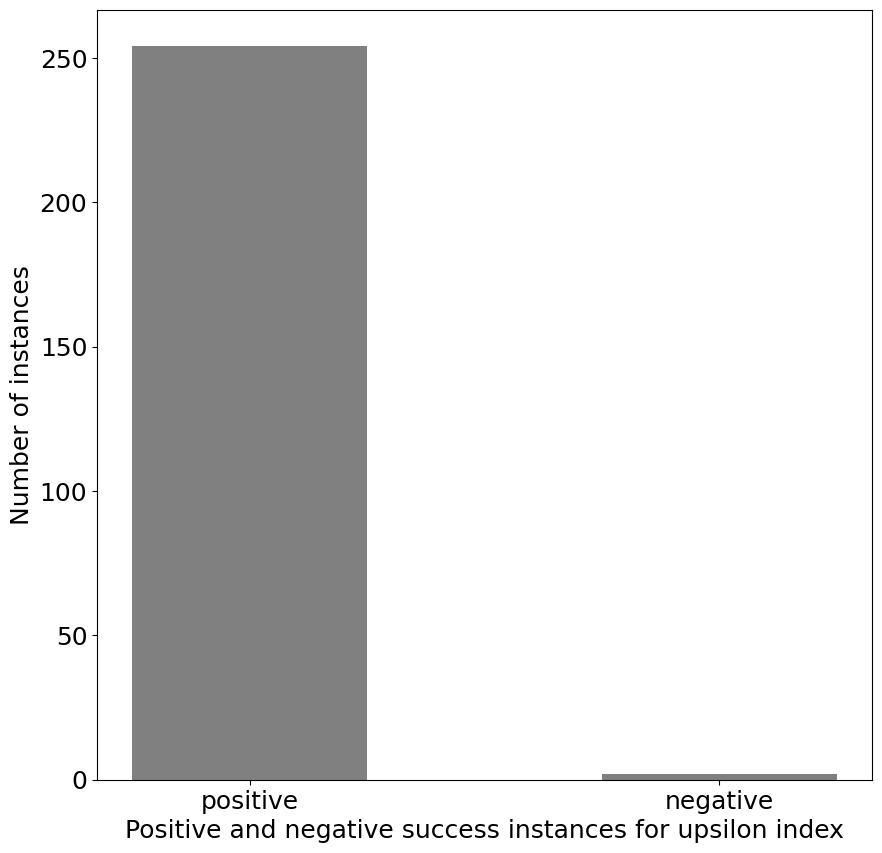

In [8]:
import matplotlib.pyplot as plt
from powerxai.banzhaf_value import banzhaf_value as bv

value_functions = binary_value_functions_over_set([0, 1, 2])
result = []

for func in value_functions:
  result.append(success_for_upsi_index([0, 1, 2], func))


pos = len([x for x in result if x == True])
neg = len(result) - pos

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative success instances for upsilon index', fontsize= 18)
plt.ylabel('Number of instances', fontsize= 18)
plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

### Counterfactual Index

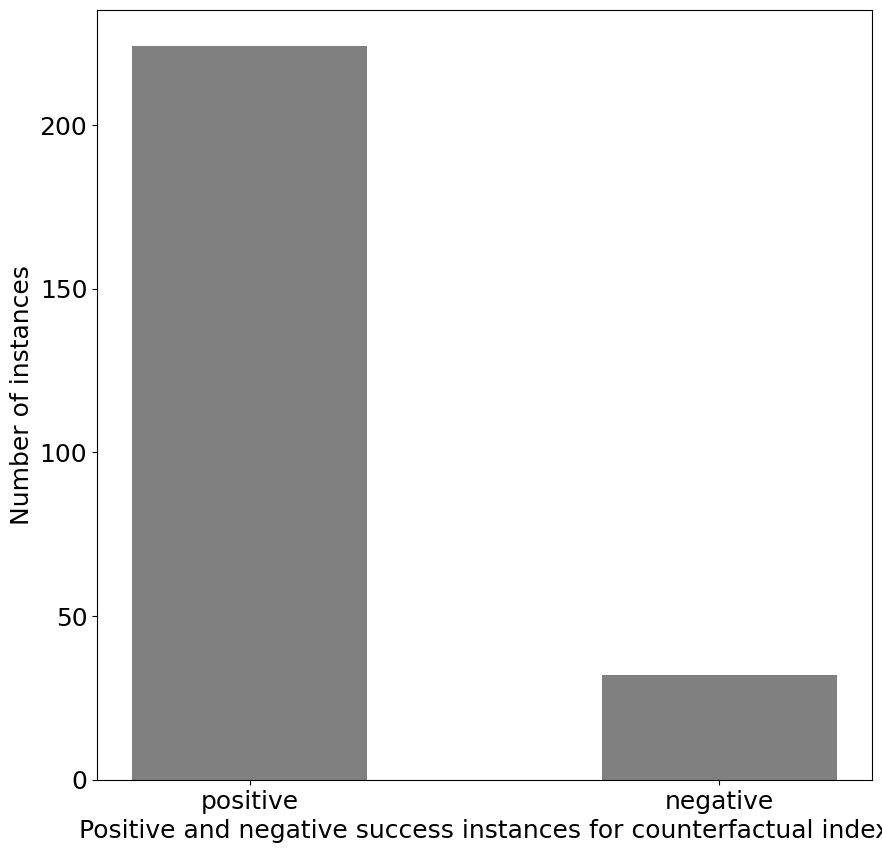

In [9]:
import matplotlib.pyplot as plt
from powerxai.banzhaf_value import banzhaf_value as bv

value_functions = binary_value_functions_over_set([1, 2, 3])
result = []

for func in value_functions:
  result.append(success_for_cardinality_index([1, 2, 3], func))

pos = len([x for x in result if x == True])
neg = len(result) - pos

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative success instances for counterfactual index', fontsize= 18)
plt.ylabel('Number of instances', fontsize= 18)
plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

### Banzhaf Index

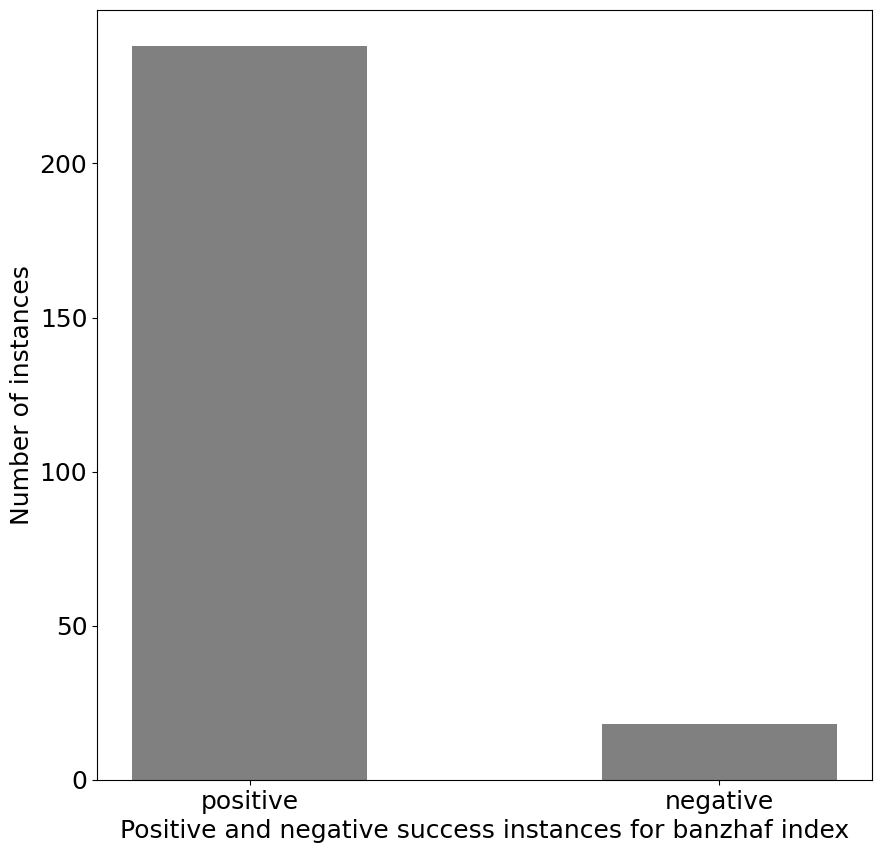

In [10]:
import matplotlib.pyplot as plt

value_functions = binary_value_functions_over_set([0, 1, 2])
result = []

for func in value_functions:
  result.append(success_for_banzhaf_index([0, 1, 2], func))

pos = len([x for x in result if x == True])
neg = len(result) - pos

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative success instances for banzhaf index', fontsize= 18)
plt.ylabel('Number of instances', fontsize= 18)
plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

### Owen Index

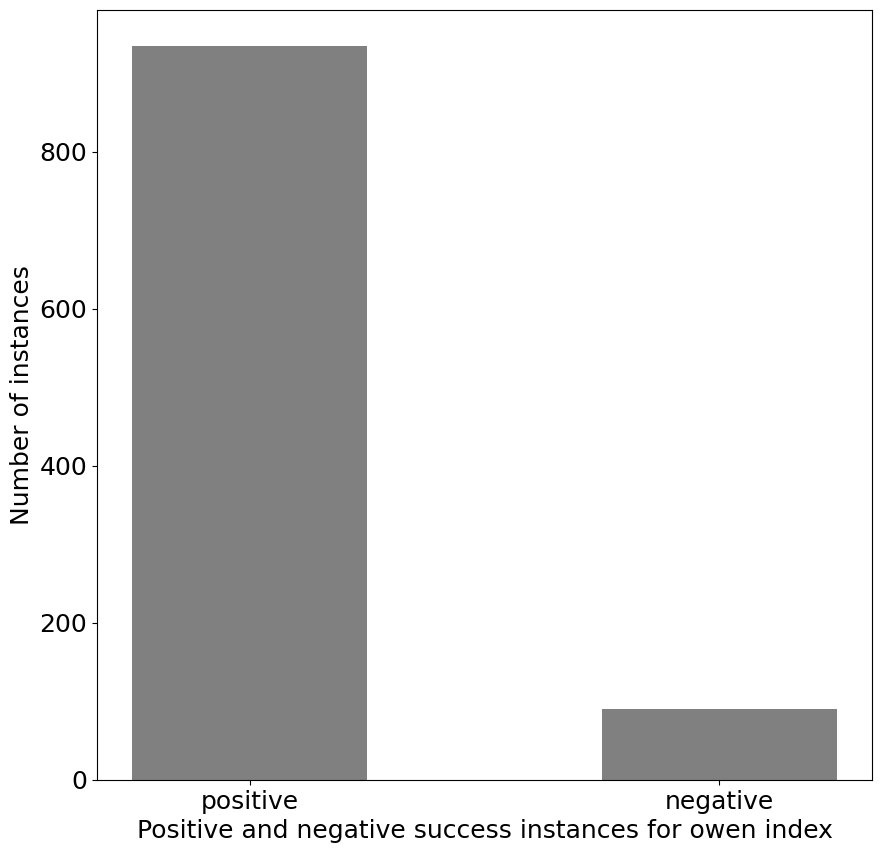

In [12]:
import matplotlib.pyplot as plt
import more_itertools as mit
from copy import copy

def partition_generator(players: list[int],
                        ) -> list[list[int]]:
    """
       Generates all the possible partitions of players.

       Args:
       players (list[int]): List of players to be partitioned.

       Returns:
       list[list[int]]: The list of all possible partitions.
    """
    list_of_partitions = []
    lst = []

    for i in range(1, len(players)+1):
      lst = []
      singular_partition = mit.set_partitions(players, i)
      for x in singular_partition:
        list_of_partitions.append(x)

    return list_of_partitions




value_functions = binary_value_functions_over_set([0, 1, 2])
result = []
part = partition_generator([0, 1, 2])
part.remove([[0], [1], [2]])

for p in part:
  for func in value_functions:
    result.append(success_for_owen_index(p, func))

pos = len([x for x in result if x == True])
neg = len(result) - pos

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative success instances for owen index', fontsize= 18)
plt.ylabel('Number of instances', fontsize= 18)
plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

### Shapley index

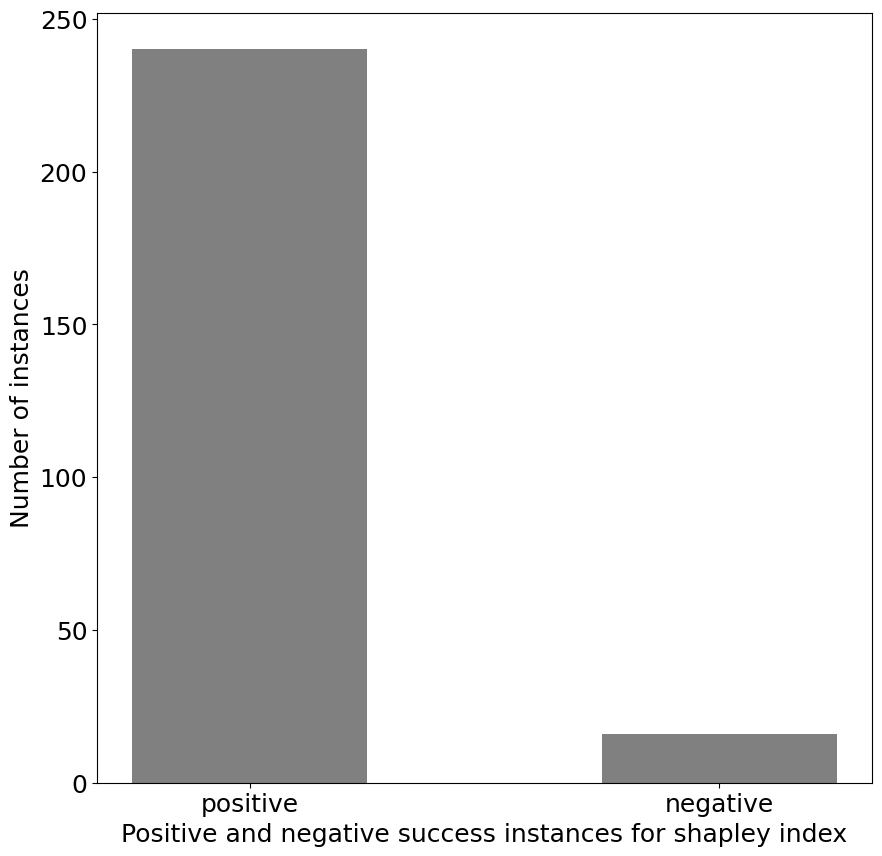

In [13]:
import matplotlib.pyplot as plt

value_functions = binary_value_functions_over_set([0, 1, 2])
result = []

for func in value_functions:
  result.append(success_for_shapley_index([0, 1, 2], func))



pos = len([x for x in result if x == True])
neg = len(result) - pos



f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative success instances for shapley index', fontsize= 18)
plt.ylabel('Number of instances', fontsize= 18)

plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

## The principle of Efficiency

Second, we consider the principle of Efficiency. Here, we proivide explicit graphs for the failure of efficiency across various power indices at hand.
We start with the indices that contradict efficiency, namely counterfactual index and Banzhaf index.

### Counterfactual Index

Here we consider the value function $v:\{{\bf x_1, x_2, x_3}\}\rightarrow \{0, 1\}$ defined as: $v(S)=1 \iff |S|=3.$

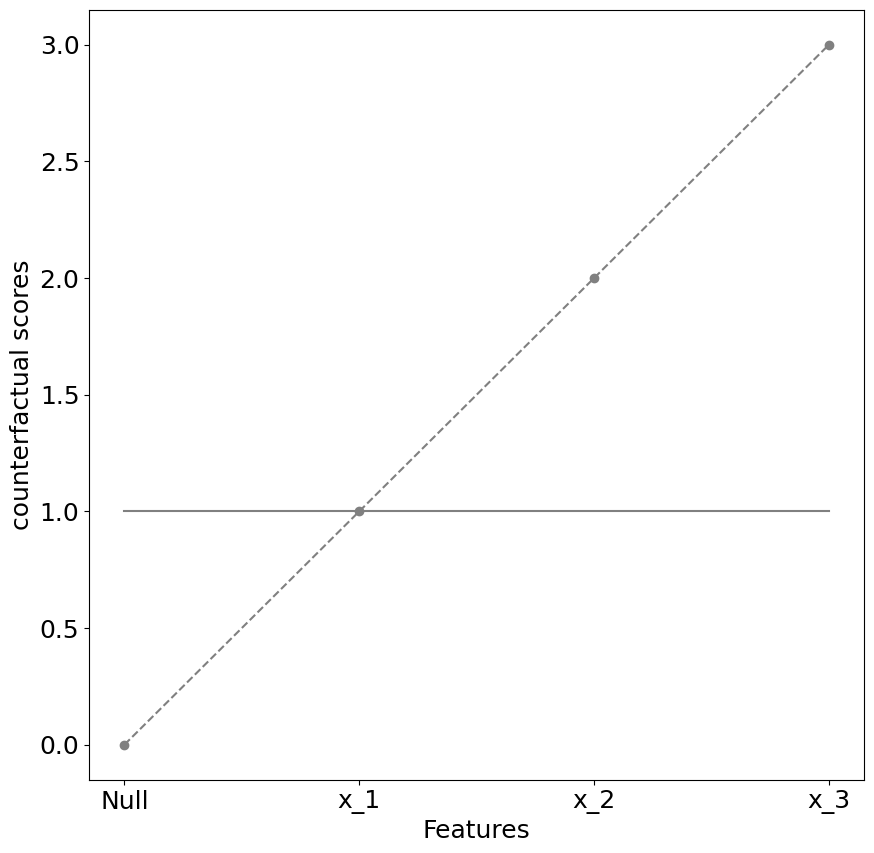

In [14]:
x_axis = [0, 1, 2, 3]
y_axis = [0, 1 ,2 ,3]

plt.figure(figsize=(10, 10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("counterfactual scores", fontsize= 18)
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker ='o')
plt.plot(x_axis, [1, 1, 1, 1], color= 'gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2, 3], ['Null', 'x_1', 'x_2', 'x_3'])

plt.show()

### Banzhaf Index

Here the value function $v:\{{\bf x_1, x_2, x_3}\}\rightarrow \{0, 1\}$ is defined as: $v(S)=1 \iff S=\{2\}\lor S=\{3\}\lor S=\{1, 2\} \lor S=\{1, 3\} \lor S=\{2, 3\}$.

[0, -0.25, 0.0, 0.25]


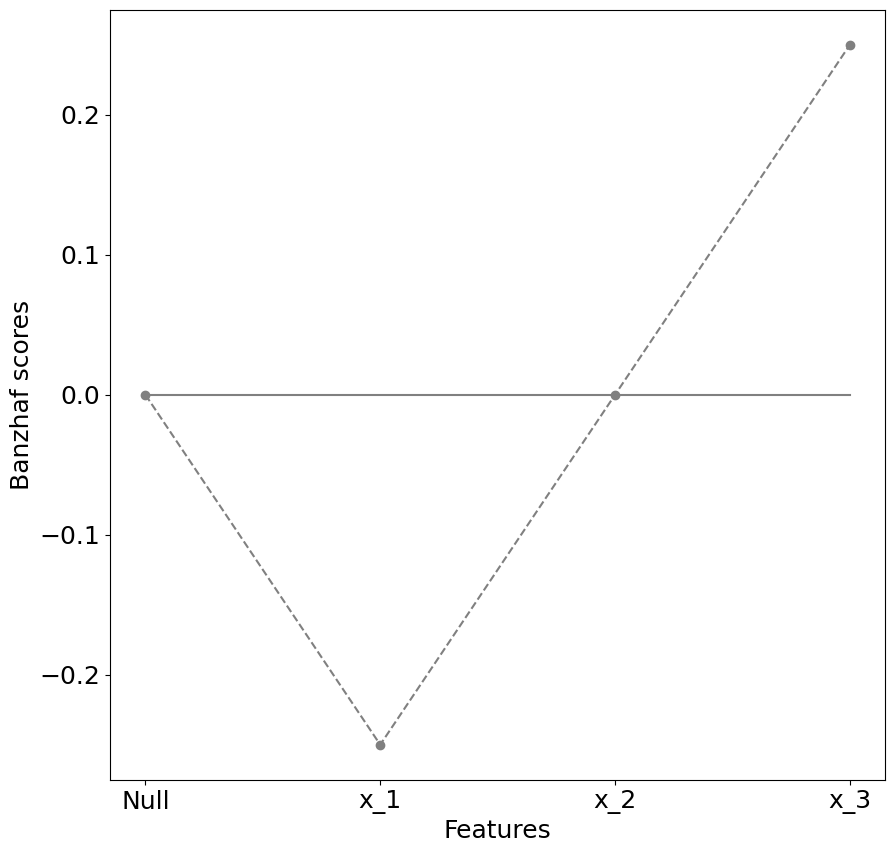

In [15]:
from powerxai.banzhaf_value import banzhaf_value as bv

x_axis = [0, 1, 2, 3]
y_axis = [0]

value_function= binary_value_function([0, 1, 2],
                                       [[1], [2], [0, 1], [0, 2], [1, 2]])

func= partial(function_dict_to_callable, set_func=value_function)
for i in range(0, 3):
  y_value = y_axis[i] + bv(i, [0, 1, 2], func, probabilistic= True)
  y_axis.append(y_value)

print(y_axis)

plt.figure(figsize=(10, 10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Banzhaf scores", fontsize= 18)
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker ='o')
plt.plot(x_axis, [0, 0, 0, 0], color='gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2, 3], ['Null', 'x_1', 'x_2', 'x_3'])

plt.show()

For the Shapley and Owen values, efficiency is satisfied. Hence we highlight certain positive examples.

### Shapley values

Here we consider the value function $v:\{{\bf x_1, x_2, x_3}\}\rightarrow \{0,1\}$, defined as: $v(S)=1 \iff S=\{{\bf x_2}\} \lor S=\{{\bf x_2, x_3}\} \lor S=\{{\bf x_1, x_2}\} \lor S=\{{\bf x_1, x_2, x_3}\}$.

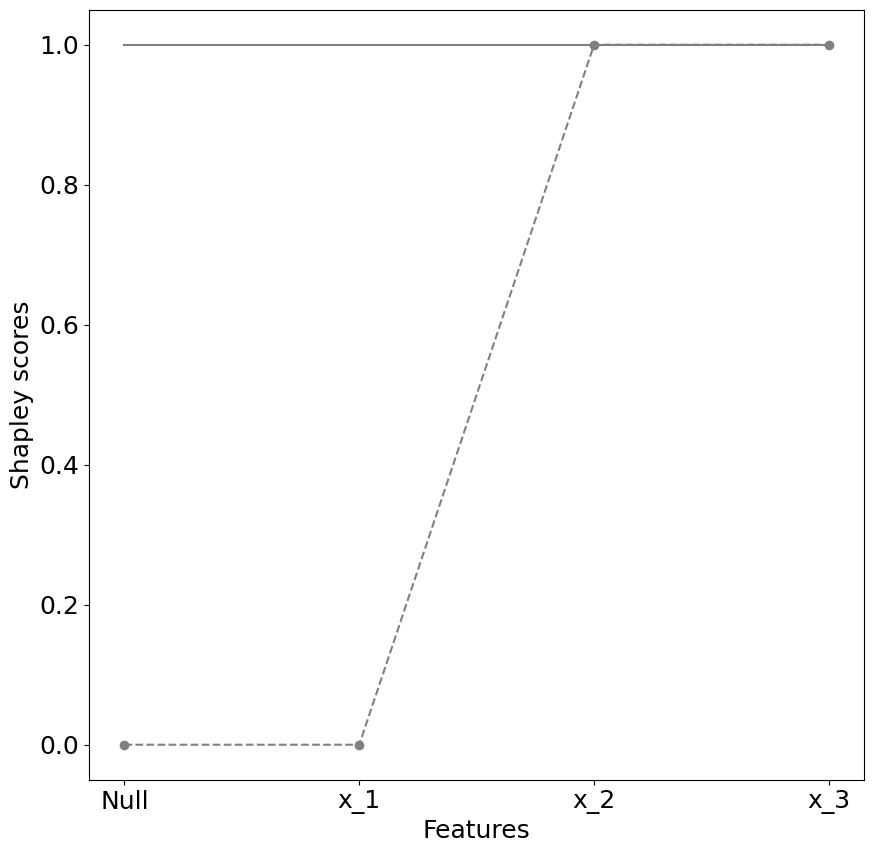

In [16]:
from powerxai.shapley_value import shapley_value as sv

x_axis = [0, 1, 2, 3]
y_axis = [0]

value_function= binary_value_function([0, 1, 2],
                                       [[1], [1, 2], [0, 1], [0, 1, 2]])

func= partial(function_dict_to_callable, set_func=value_function)
for i in range(0, 3):
  y_value = y_axis[i] + sv(i, [0, 1, 2], func)
  y_axis.append(y_value)

plt.figure(figsize=(10, 10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Shapley scores", fontsize= 18)
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker ='o')
plt.plot(x_axis, [1, 1, 1, 1], color='gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2, 3], ['Null', 'x_1', 'x_2', 'x_3'])

plt.show()

### Owen values

For owen values, we consider the same value function as Shapley, with the feature union $P_1=\{{\bf x_1, x_2}\}, P_2=\{{\bf x_3}\}$.

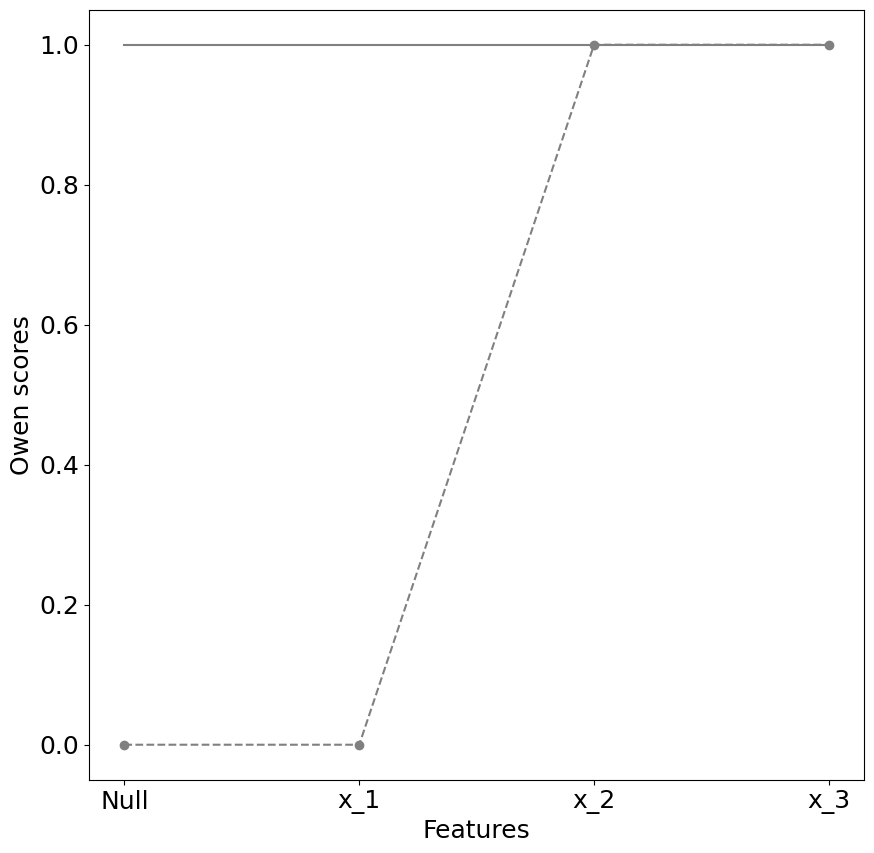

In [17]:
from powerxai.owen_value import owen_value as ov

x_axis = [0, 1, 2, 3]
y_axis = [0]

value_function= binary_value_function([0, 1, 2],
                                       [[1], [1, 2], [0, 1], [0, 1, 2]])

func= partial(function_dict_to_callable, set_func=value_function)
for i in range(0, 3):
  y_value = y_axis[i] + ov(i, [[0, 1], [2]], func)
  y_axis.append(y_value)

plt.figure(figsize=(10, 10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Owen scores", fontsize= 18)
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker ='o')
plt.plot(x_axis, [1, 1, 1, 1], color='gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2, 3], ['Null', 'x_1', 'x_2', 'x_3'])

plt.show()

### Upsilon values

Again, we use the same value function as Shapley for Upsilon values.

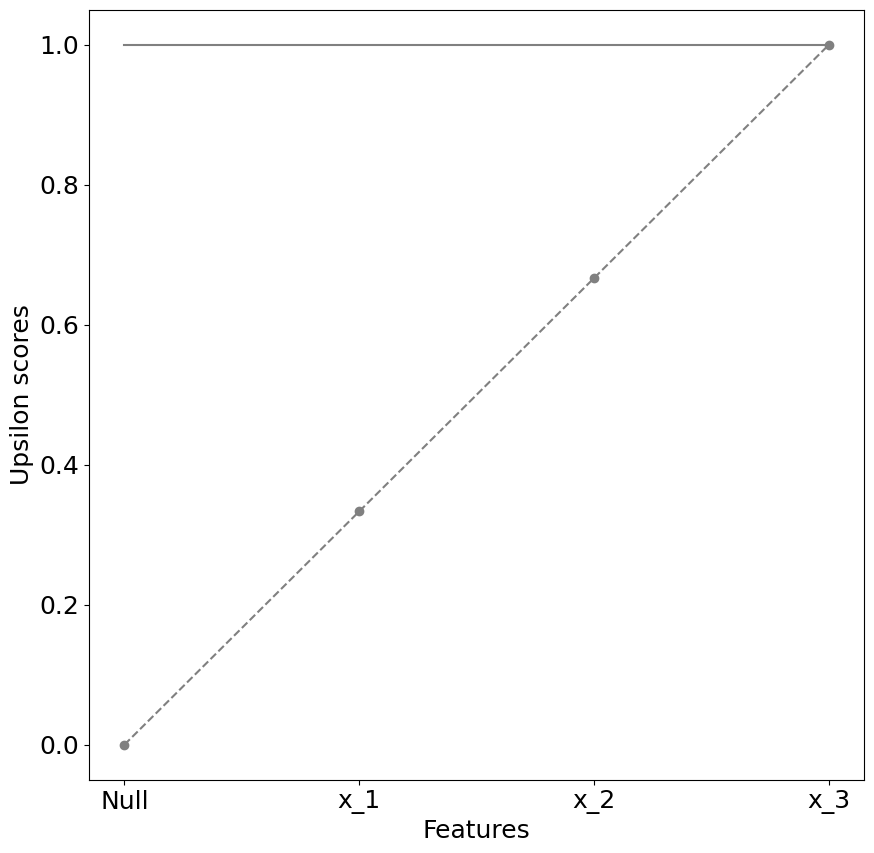

In [18]:
from powerxai.upsilon_value import upsilon_value as uv

x_axis = [0, 1, 2, 3]
y_axis = [0]

value_function= binary_value_function([0, 1, 2],
                                       [[1], [1, 2], [0, 1], [0, 1, 2]])

func= partial(function_dict_to_callable, set_func=value_function)
for i in range(0, 3):
  y_value = y_axis[i] + uv(i+1, [0, 1, 2], func)
  y_axis.append(y_value)

plt.figure(figsize=(10, 10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Upsilon scores", fontsize= 18)
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker ='o')
plt.plot(x_axis, [1, 1, 1, 1], color='gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2, 3], ['Null', 'x_1', 'x_2', 'x_3'])

plt.show()

## The principles of weak anonymity, null player and symmetry

All the power indices satisfy the principles of weak anonymity, null player and symmetry.
Hence, we pick an arbitrary power index and highlight an (positive) instance of each.

### Weak anonymity

We use the Shapley index to highlight weak anonymity w.r.t. the value function $v:\{{\bf x_1, x_2, x_3}\}→ \{0,1\}$ defined as: $v(S)=1 \iff S=\{{\bf x_1, x_2}\}\lor S=\{{\bf x_2, x_3}\}\lor S=\{{\bf x_1, x_2, x_3}\}$.
We exchange the indexing of features $\bf x_1$ and $\bf x_2$, keeping $\bf x_3$ the same.

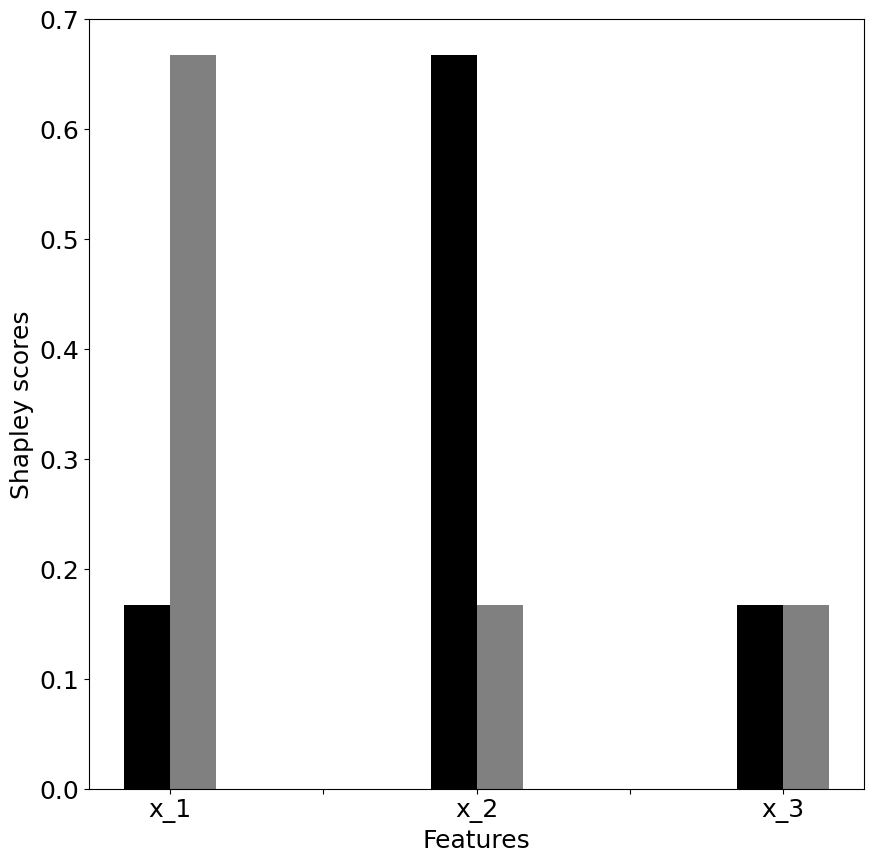

In [19]:
from powerxai.shapley_value import shapley_value as sv

x_axis =[0, 2, 4]
width= 0.3
value_function = binary_value_function([0, 1, 2],
                                       [[0, 1], [1, 2], [0, 1, 2]])
value_function_dash = binary_value_function([0, 1, 2],
                                       [[0, 1], [0, 2], [0, 1, 2]])
v= partial(function_dict_to_callable, set_func=value_function)
v_dash= partial(function_dict_to_callable, set_func=value_function_dash)

func_v = []
func_v_dash =[]

for i in range(0, 3):
  func_v.append(sv(i, [0, 1, 2], v))
  func_v_dash.append(sv(i, [0, 1, 2], v_dash))



plt.figure(figsize= (10,10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Shapley scores", fontsize=18)
plt.xticks([0, 1, 2, 3, 4], ['x_1', '', 'x_2', '', 'x_3'],fontsize=18)
plt.yticks(fontsize=18)
plt.bar([x-(width/2) for x in x_axis], func_v, color='black', width=width)
plt.bar([x+(width/2) for x in x_axis], func_v_dash, color='gray', width=width)


plt.show()

### Symmetry

For the principle of symmetry, we use the value function $v:\{{\bf x_1, x_2, x_3}\} \rightarrow \{0, 1\}$ defined as $v(S)=1 \iff S=\{{\bf x_1}\}\lor S=\{{\bf x_2}\}$, w.r.t. the Banzhaf index.  

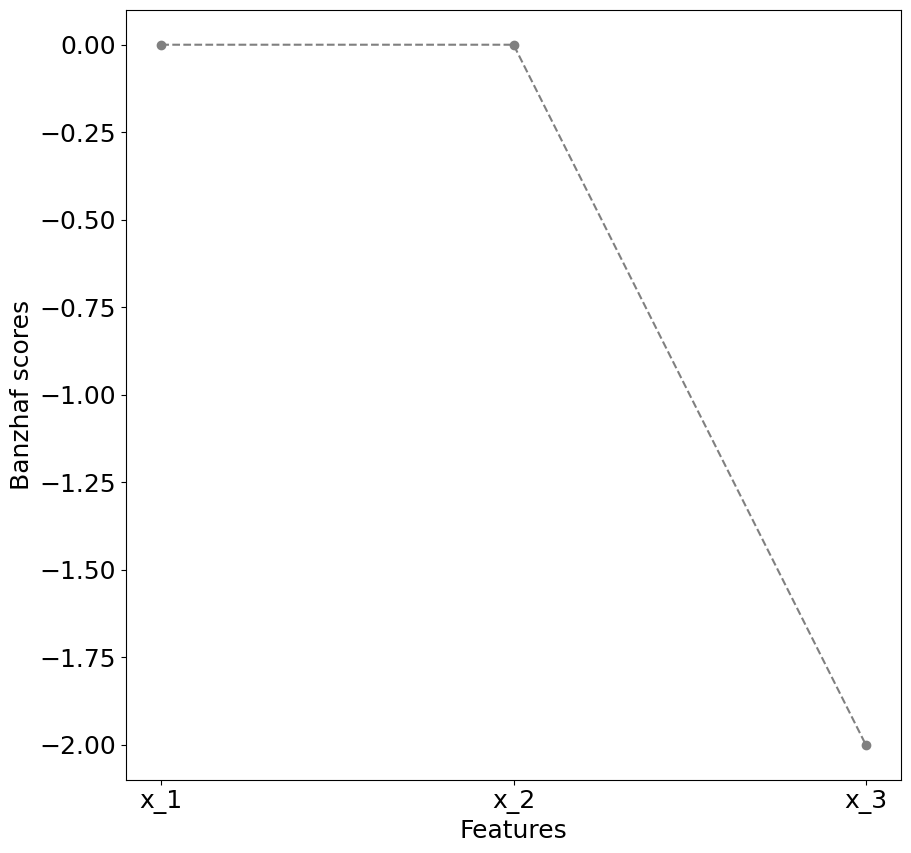

In [20]:
from powerxai.banzhaf_value import banzhaf_value as bv

value_function = binary_value_function([0, 1, 2],
                                       [[0], [1]])
func = partial(function_dict_to_callable, set_func=value_function)

x_axis= [1, 2, 3]
y_axis= [bv(i, [0, 1, 2], func, probabilistic= False) for i in range(0, 3)]

plt.figure(figsize= (10,10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Banzhaf scores", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([1, 2, 3], ['x_1', 'x_2', 'x_3'])
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker = 'o')

plt.show()

### Null player

For the principle of null player, we use the value function $v:\{{\bf x_1, x_2, x_3}\} \rightarrow \{0, 1\}$ defined as $v(S)=1 \iff S=\{{\bf x_2, x_3}\}\lor S=\{{\bf x_1, x_2, x_3}\}$, w.r.t. the Owen index.
The partition considered is $P_1=\{{\bf x_1, x_2}\}$ and $P_2=\{{\bf x_3}\}$.  

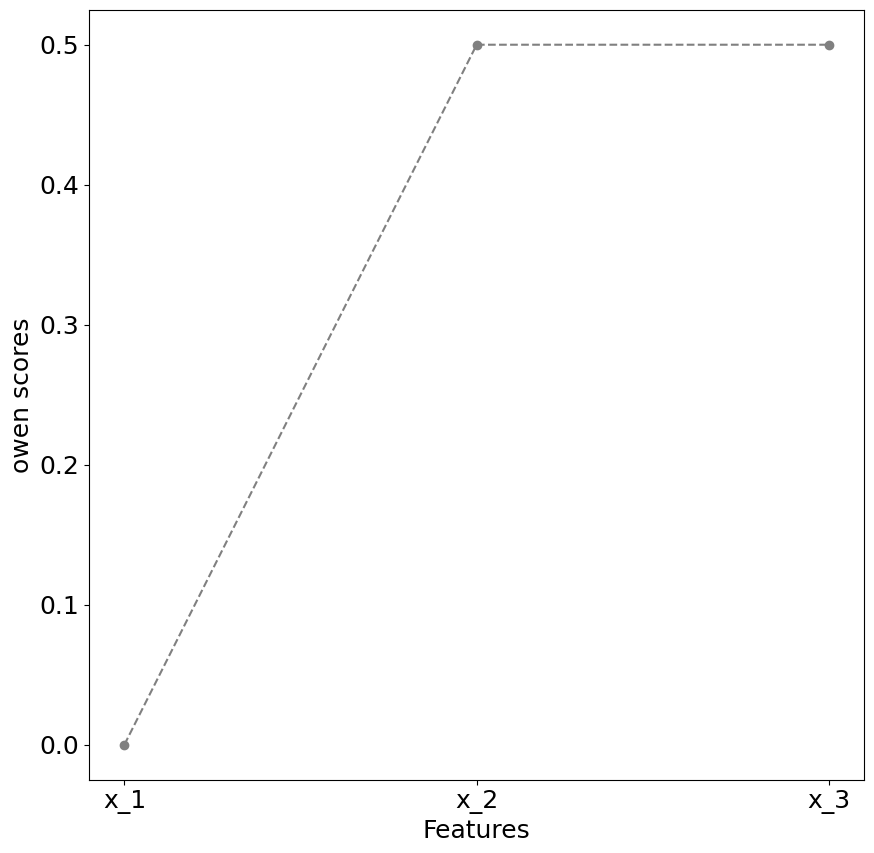

In [21]:
from powerxai.owen_value import owen_value as ov

value_function = binary_value_function([0, 1, 2],
                                       [[1, 2], [0, 1, 2]])
func = partial(function_dict_to_callable, set_func=value_function)

x_axis= [1, 2, 3]
y_axis= [ov(i, [[0, 1], [2]], func) for i in range(0, 3)]


plt.figure(figsize= (10,10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("owen scores", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([1, 2, 3], ['x_1', 'x_2', 'x_3'])
plt.plot(x_axis, y_axis, color= 'gray', linestyle= 'dashed', marker = 'o')

plt.show()

## Principles of counterfactulity and quantitative counterfactuality

The examples corrsponding to both coincide. We take a similar approach to the principle of success, highlighting the positive and negative instances for all the binary value functions w.r.t. the Shapley index.
We skip the others for the sake of brevity.

True


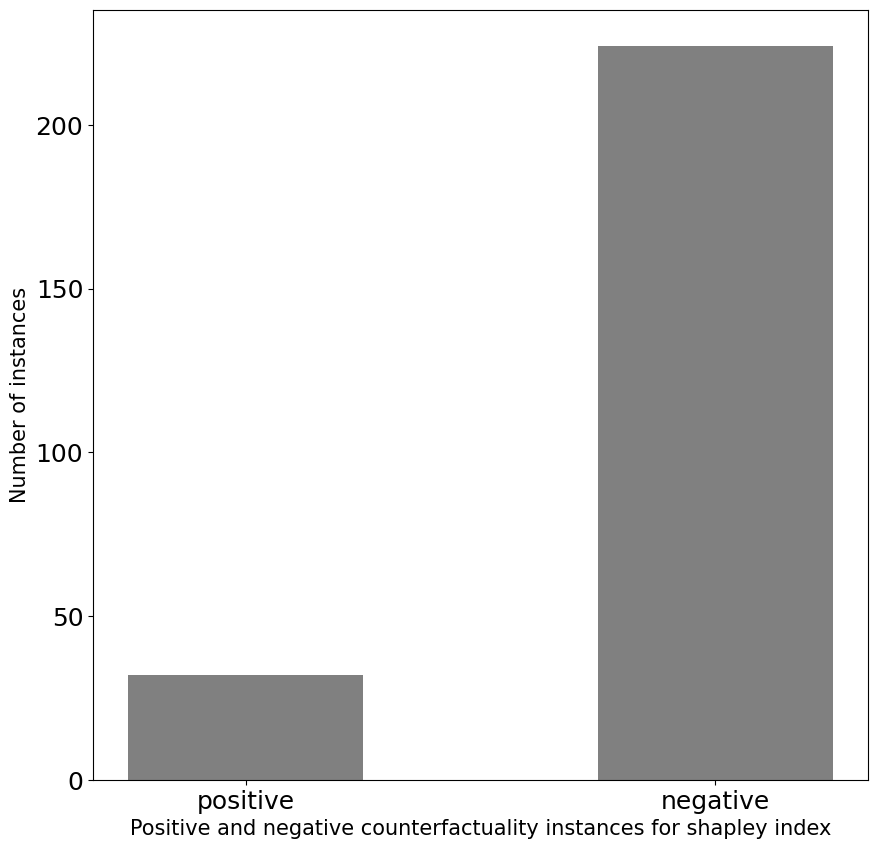

In [22]:
def cf_analysis_shapley(players: list[int],
                        value_function: dict
                        ) -> bool:
    """
       Checks whether the counterfcatuality principle is satisfied w.r.t. the Shapley index.

       Args:
       players (list[int]): List of players to be passed on.
       value_function (dict): The value function.

       Returns:
       bool: True if the principle is satisfied, False otherwise.
    """
    func = partial(function_dict_to_callable, set_func=value_function)
    values = [sv(i, [0, 1, 2], func) for i in range(0, 3)]


    for i in range(0, 3):

      f = {0, 1, 2}
      f. remove(i)
      cf_val = func([0, 1, 2], {0, 1, 2}) - func([0, 1, 2], f)



      if((values[i] < 0.0) and (cf_val >= 0.0)):
        return False
      elif((values[i] == 0) and (cf_val != 0.0)):
        return False
      elif((values[i] > 0.0 ) and (cf_val <= 0.0)):
        return False

    return True


value_function = binary_value_function([0, 1, 2],
                                       [[0, 1, 2]])
print(cf_analysis_shapley([0, 1, 2], value_function))



value_functions = binary_value_functions_over_set([0, 1, 2])
result = []

for func in value_functions:
  result.append(cf_analysis_shapley([0, 1, 2], func))



pos = len([x for x in result if x == True])
neg = len(result) - pos



f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

plt.bar(['positive', 'negative'], [pos, neg], color= 'gray', width= 0.5)
plt.xlabel('Positive and negative counterfactuality instances for shapley index', fontsize= 15)
plt.ylabel('Number of instances', fontsize= 15)

plt.xticks(fontsize= 18)
plt.yticks(fontsize= 18)

plt.show()

We move onto the cardinality based principles, namely dummy cardinality, absoluet anonymity and cardinality based counterfactuality.
For each, we provide an example concerning the upsilon index.

### Principle of dummy cardinality

For this principle, we employ the value function $v:\{{\bf x_1, x_2, x_3}\}→\{0,1\}$ defined as: $v(S)=1 \iff |S|=3.$
Notice that the line graph below showcases the positive instance.

[0.0, 0.0, 1.0]


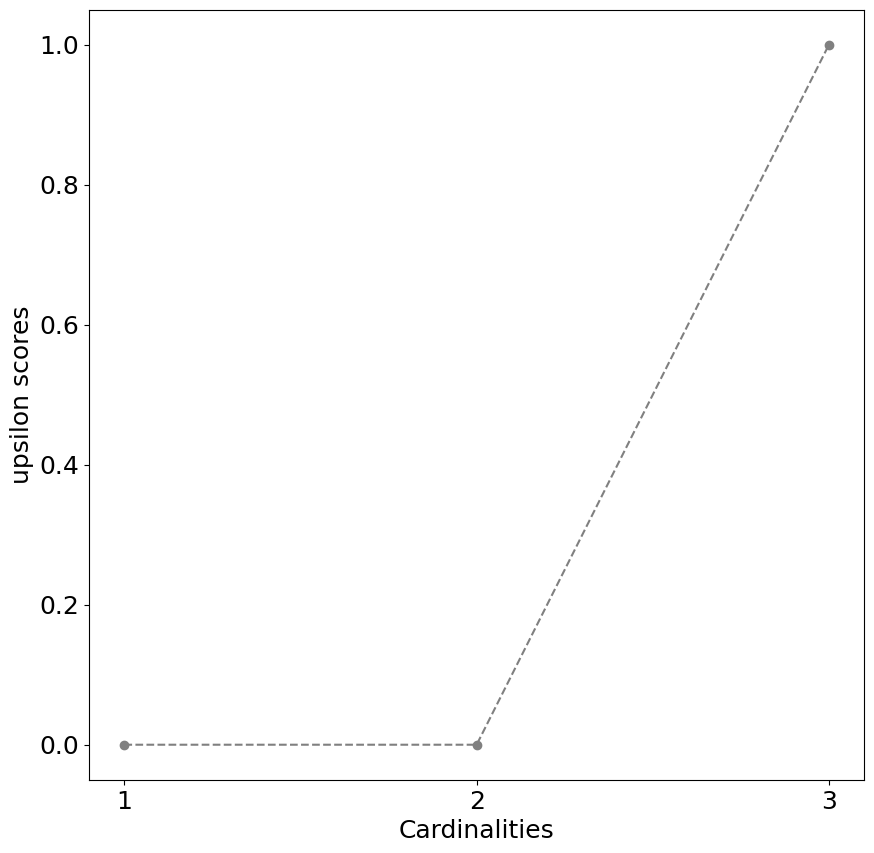

In [23]:
value_function = binary_value_function([0, 1, 2],
                                       [[0, 1, 2]])
func = partial(function_dict_to_callable, set_func=value_function)

values = [uv(i+1, [0, 1, 2], func) for i in range(0, 3)]
print(values)

x_axis = [1, 2, 3]

plt.figure(figsize= (10,10))
plt.xlabel("Cardinalities", fontsize= 18)
plt.ylabel("upsilon scores", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([1, 2, 3], ['1', '2', '3'])
plt.plot(x_axis, values, color= 'gray', linestyle= 'dashed', marker = 'o')

plt.show()

### Principle of absolute anonymity

We plot the bar graph of the value function $v:\{{\bf x_1, x_2, x_3}\}→ \{0,1\}$ defined as: $v(S)=1 \iff S=\{{\bf x_1, x_2}\}\lor S=\{{\bf x_2, x_3}\}\lor S=\{{\bf x_1, x_2, x_3}\}$.
We exchange the indexing of features $\bf x_1$ and $\bf x_2$, keeping $\bf x_3$ the same. Notice that the upsilon scores remain unchanged at the face of function change.

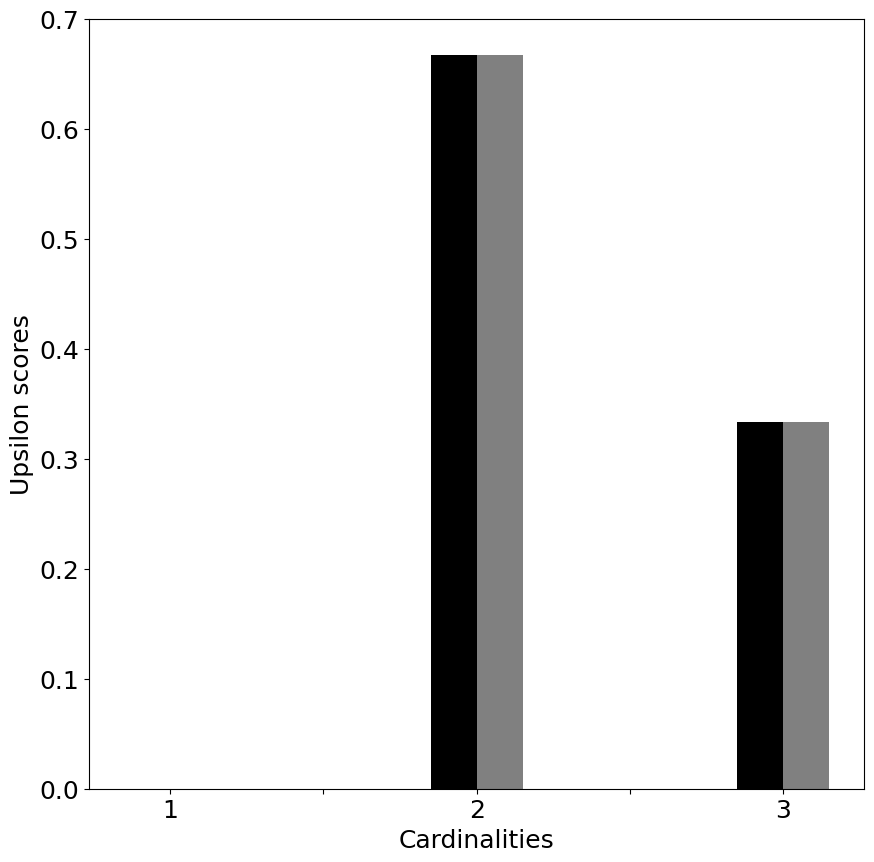

In [24]:
x_axis =[0, 2, 4]
width= 0.3
value_function = binary_value_function([0, 1, 2],
                                       [[0, 1], [1, 2], [0, 1, 2]])
value_function_dash = binary_value_function([0, 1, 2],
                                       [[0, 1], [0, 2], [0, 1, 2]])
v= partial(function_dict_to_callable, set_func=value_function)
v_dash= partial(function_dict_to_callable, set_func=value_function_dash)

func_v = []
func_v_dash =[]

for i in range(0, 3):
  func_v.append(uv(i+1, [0, 1, 2], v))
  func_v_dash.append(uv(i+1, [0, 1, 2], v_dash))



plt.figure(figsize= (10,10))
plt.xlabel("Cardinalities", fontsize= 18)
plt.ylabel("Upsilon scores", fontsize=18)
plt.xticks([0, 1, 2, 3, 4], ['1', '', '2', '', '3'],fontsize=18)
plt.yticks(fontsize=18)
plt.bar([x-(width/2) for x in x_axis], func_v, color='black', width=width)
plt.bar([x+(width/2) for x in x_axis], func_v_dash, color='gray', width=width)


plt.show()

### Principle of cardinality based counterfactuality

Finally, we provide an example for cardinality based counterfactuality w.r.t. the value function $v$ defined as $v(S)=1 \iff S=\{{\bf x_2, x_3}\}\lor S=\{{\bf x_1, x_2, x_3}\}$.

The scatter plot below shops the difference between upsilon values and the valued obtained after removing a cardnility. The 0-line indicated by blue denotes the failure of cardinality based counterfactuality: If all the ploted points lie on either side of the line, or on the line, then the principle is satisfied. Notice that the previous condition is violated for cardinality 1.

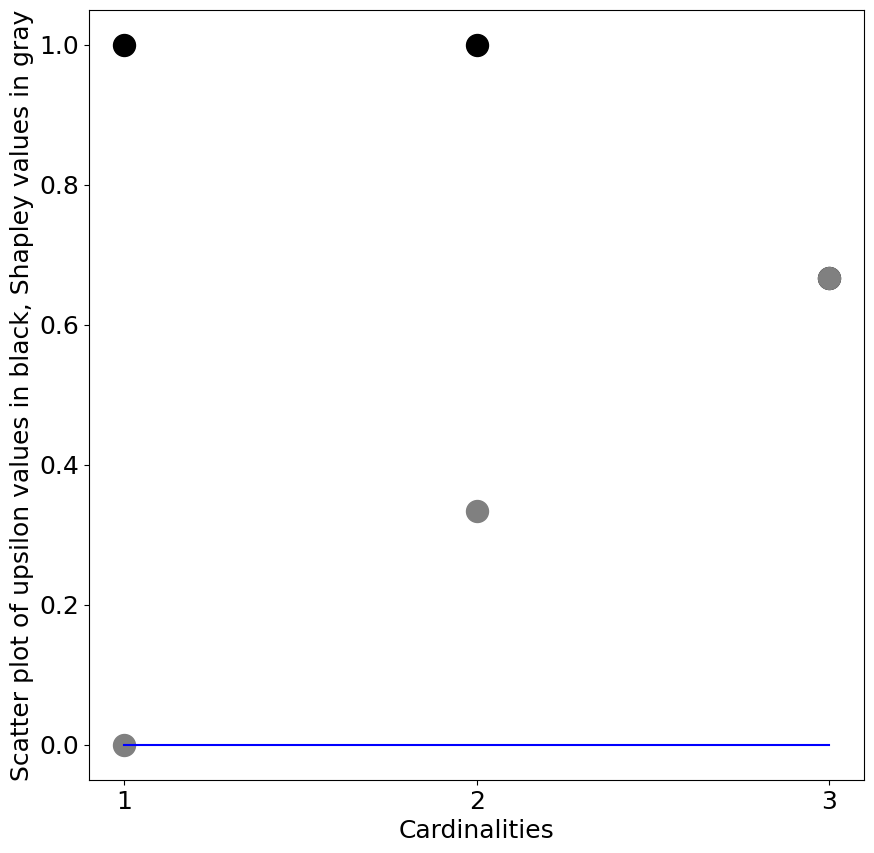

In [25]:
from powerxai.coalitions import coalitions
import math

def cf_analysis_upsi(players: list[int],
                     player: int,
                     value_function: Any
                     )-> float:
    """
       Retruns the value of whole coalition minus the cardinality of player.

       Args:
       players (list[int]): List of players to be passed on.
       player (int): The cardinality whose value is to be returned.
       value_function (Any): The value function.

       Returns:
       float: the value after emoving the cardinality.
    """
    sum = 0
    for group in coalitions(players, player):
      sum = sum + value_function(players, group)

    sum = sum / (math.comb (len(players), player))
    return value_function(players, players) - sum


value_function = binary_value_function([0, 1, 2],
                                       [[1, 2], [0, 1, 2]])
func = partial(function_dict_to_callable, set_func=value_function)

x_axis= [1, 2, 3]
values= [cf_analysis_upsi([0, 1, 2], i, func) for i in range(0, 3)]
upsi_values = [uv(i+1, [0, 1, 2], func) for i in range(0, 3)]



plt.figure(figsize= (10,10))
plt.xlabel("Cardinalities", fontsize= 18)
plt.ylabel("Scatter plot of upsilon values in black, Shapley values in gray", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([0, 1, 2], ['1', '2', '3'])
plt.scatter([0, 1, 2], values, color= 'black', s=250)
plt.scatter([0, 1, 2], upsi_values, color= 'gray', s=250)
plt.plot([0, 1, 2], [0, 0, 0], color= 'blue')

plt.show()

<Figure size 1000x1000 with 0 Axes>

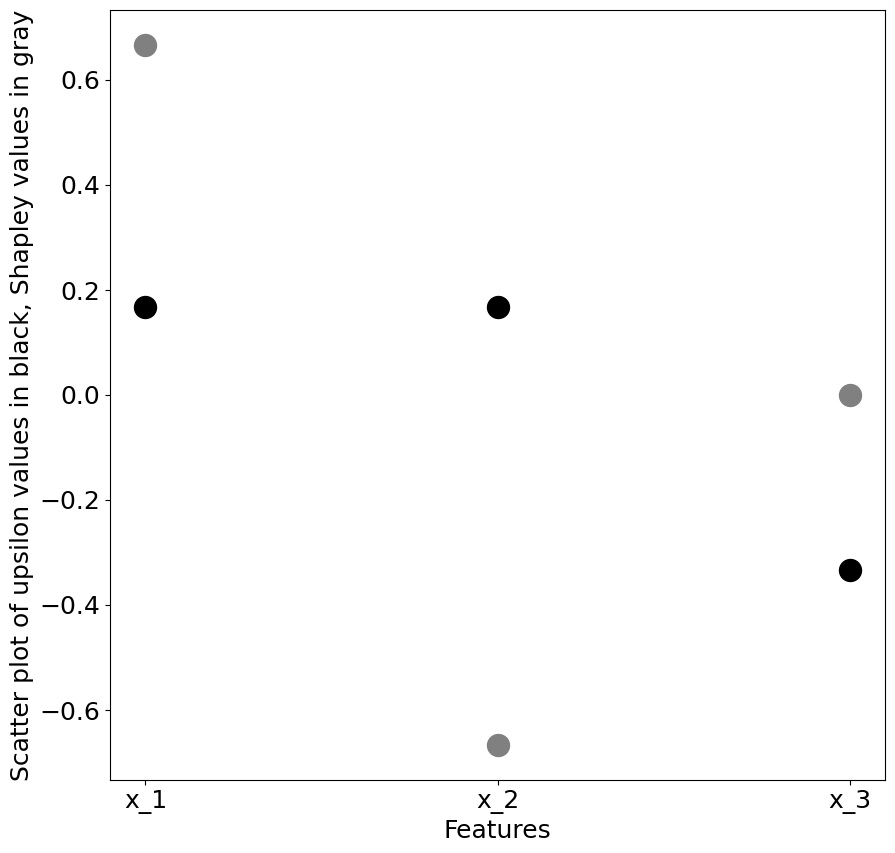

In [28]:
from powerxai.upsilon_value import upsilon_value as uv

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(10)

x_axis = [-0.1, 0.9, 1.9]
x_axis_dash = [0.1, 1.1, 2.1]
y_axis = [0]
value_function = binary_value_function([0, 1, 2],
                                       [[0], [1]])


func = partial(function_dict_to_callable, set_func=value_function)

v_shapley=[sv(i, [0, 1, 2], func) for i in range(0, 3)]
v_upsilon_values=[uv(i+1, [0, 1, 2], func) for i in range(0, 3)]


plt.figure(figsize= (10,10))
plt.xlabel("Features", fontsize= 18)
plt.ylabel("Scatter plot of upsilon values in black, Shapley values in gray", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xticks([1, 2, 3], ['x_1', 'x_2', 'x_3'])
plt.scatter([1, 2, 3], v_shapley, color= 'black', s=250)
plt.scatter([1, 2, 3], v_upsilon_values, color= 'gray', s=250)

plt.show()